In [1]:
# importing all the libraries i need
import os
os.environ["PYTHONUTF8"] = "1"
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from keras import layers
from tensorflow import losses
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")
print(f"NumPy Version: {np.__version__}")
print("all imports done!")

TensorFlow Version: 2.21.0
NumPy Version: 2.4.2
all imports done!


In [2]:
print("Loading spam.csv ...")

# load the csv file using pandas
# encoding='latin-1' is needed otherwise it gives an error
df = pd.read_csv("spam.csv", encoding='latin-1', usecols=['v1', 'v2'])

# rename columns to something more readable
df.columns = ['label', 'message']

print("Dataset loaded!")
print(f"Total rows: {len(df)}")
print()
print("First 5 rows:")
print(df.head())

Loading spam.csv ...
Dataset loaded!
Total rows: 5572

First 5 rows:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


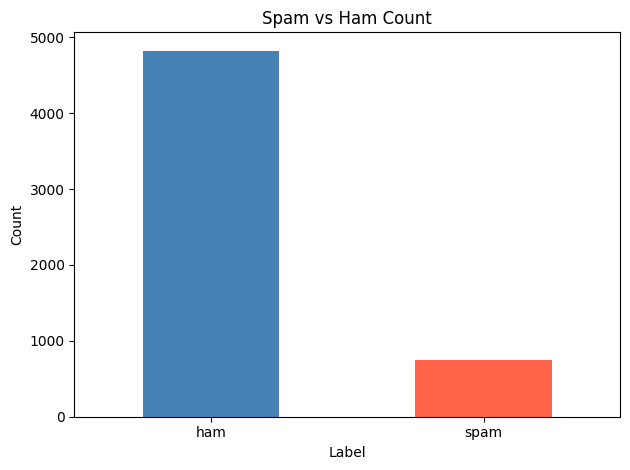

In [3]:
# checking how many spam vs ham messages we have
print("Class distribution:")
print(df['label'].value_counts())

# plotting it to see the imbalance
df['label'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Spam vs Ham Count')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# NOTE: there is a big class imbalance here
# ham = 4825, spam = 747
# this means we need to handle it during training using class weights

In [4]:
# convert labels to numbers: ham=0, spam=1
df['numeric_label'] = (df['label'] == 'spam').astype(int)

# get actual dataset size from the dataframe (dont hardcode it!)
DATASET_SIZE = len(df)
print(f"Dataset size: {DATASET_SIZE}")

# convert to tensorflow dataset
dataset = tf.data.Dataset.from_tensor_slices(
    (df['message'].values, df['numeric_label'].values)
)

# shuffle dataset before splitting
dataset = dataset.shuffle(buffer_size=DATASET_SIZE, seed=42, reshuffle_each_iteration=False)

# 80/20 train test split
train_size = int(0.8 * DATASET_SIZE)
print(f"Train size: {train_size}")
print(f"Test size: {DATASET_SIZE - train_size}")

train_ds = dataset.take(train_size).batch(32)
test_ds = dataset.skip(train_size).batch(32)

Dataset size: 5572
Train size: 4457
Test size: 1115


In [5]:
print("Setting up text vectorization...")

# i increased sequence_length to 150 because some spam messages are long
max_features = 5000
sequence_length = 150

vectorize_layer = layers.TextVectorization(
    standardize='lower_and_strip_punctuation',
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length
)

# adapt the vectorizer only on training text (not test!)
train_text_only = train_ds.map(lambda x, y: x)
vectorize_layer.adapt(train_text_only)

print("Vocabulary size:", len(vectorize_layer.get_vocabulary()))

# apply vectorization to both datasets
def vectorize_text(text, label):
    return vectorize_layer(text), label

train_ds = train_ds.map(vectorize_text)
test_ds = test_ds.map(vectorize_text)

# caching makes training faster
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Vectorization done!")

Setting up text vectorization...
Vocabulary size: 5000
Vectorization done!


In [6]:
# because ham=4825 and spam=747, the model will be biased towards ham
# class weights help fix this problem
# basically we tell the model to pay more attention to spam samples

ham_count = (df['label'] == 'ham').sum()
spam_count = (df['label'] == 'spam').sum()

# spam gets a higher weight because there are fewer of them
class_weight = {
    0: 1.0,                        # ham weight
    1: ham_count / spam_count      # spam weight (~6.46)
}

print("Class weights:")
print(f"  Ham (0):  {class_weight[0]:.2f}")
print(f"  Spam (1): {class_weight[1]:.2f}")

Class weights:
  Ham (0):  1.00
  Spam (1): 6.46


In [7]:
print("Building the model...")

embedding_dim = 16

model = tf.keras.Sequential([
    layers.Embedding(max_features, embedding_dim),
    layers.Dropout(0.2),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')  # sigmoid for binary classification
])

# using precision and recall because accuracy alone is misleading
# when the dataset is imbalanced like ours
model.compile(
    loss=losses.BinaryCrossentropy(),
    optimizer='adam',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

model.summary()

Building the model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
print("Starting training...")

# early stopping will stop training when val_loss stops improving
# this way we dont have to manually pick number of epochs
# patience=5 means it will wait 5 more epochs before stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True  # keep the best version of the model
)

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=100,           # max epochs, early stopping will stop it earlier
    class_weight=class_weight,
    callbacks=[early_stop]
)

print("Training finished!")

Starting training...
Epoch 1/100


140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7368 - loss: 1.1780 - precision: 0.1463 - recall: 0.2128 - val_accuracy: 0.8484 - val_loss: 0.6542 - val_precision: 0.5000 - val_recall: 0.0059
Epoch 2/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7972 - loss: 1.1576 - precision: 0.2492 - recall: 0.2803 - val_accuracy: 0.9157 - val_loss: 0.6484 - val_precision: 0.8947 - val_recall: 0.5030
Epoch 3/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8075 - loss: 1.1316 - precision: 0.3093 - recall: 0.3927 - val_accuracy: 0.9444 - val_loss: 0.6453 - val_precision: 0.7585 - val_recall: 0.9290
Epoch 4/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8261 - loss: 1.0932 - precision: 0.3823 - recall: 0.5536 - val_accuracy: 0.9363 - val_loss: 0.6200 - val_precision: 0.7227 - val_recall: 0.9408
Epoch 5/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8732 - loss: 1.0380 - precision: 0.5084 - recall: 0.6799 - val_accuracy: 0.9363 - val_loss: 0.5824 - 

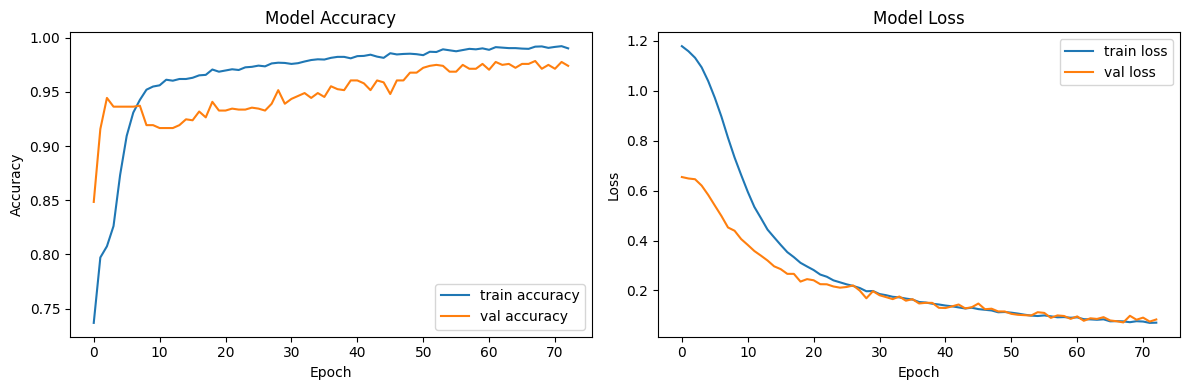

In [9]:
# plot accuracy and loss curves to see how training went
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# accuracy plot
axes[0].plot(history.history['accuracy'], label='train accuracy')
axes[0].plot(history.history['val_accuracy'], label='val accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# loss plot
axes[1].plot(history.history['loss'], label='train loss')
axes[1].plot(history.history['val_loss'], label='val loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
print("Evaluating on test set...")
loss, accuracy, precision, recall = model.evaluate(test_ds)

# f1 score combines precision and recall into one number
# i learned this formula from class
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

print()
print("======== Final Results ========")
print(f"Loss:      {loss:.4f}")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1 Score:  {f1 * 100:.2f}%")
print("================================")

Evaluating on test set...
 1/35 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9688 - loss: 0.0651 - precision: 1.0000 - recall: 0.8889

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9785 - loss: 0.0723 - precision: 0.9006 - recall: 0.9645

======== Final Results ========
Loss:      0.0723
Accuracy:  97.85%
Precision: 90.06%
Recall:    96.45%
F1 Score:  93.14%


In [14]:
export_model = tf.keras.Sequential([
    vectorize_layer,
    model])


export_model.compile(
    loss=losses.BinaryCrossentropy(),
    optimizer='adam',
    metrics=['accuracy'])


# save so i dont have to retrain every time
export_model.save("spam_classifier.h5")
print("Model saved as spam_classifier.h5")

Model saved as spam_classifier.h5


In [ ]:
print("Testing the classifier on some sample messages...")

sample_messages = np.array([
                            "Hey, what time are we meeting up for project work?",
                            "URGENT: Click here to claim your free reward voucher right now!",
                            "Can you send me the notes from todays lecture?",
                            "Congratulations! You have won a 1000 dollar prize. Call now to claim!",
                            "Are you coming to the study group tonight?",
                            ], dtype=object)

predictions = export_model.predict(sample_messages)

print()
print("===== Classification Results =====")
for msg, score in zip(sample_messages, predictions):
    verdict = "SPAM" if score[0] >= 0.5 else "HAM (Safe)"
    print(f"Message : {msg}")
    print(f"Score   : {score[0]*100:.2f}% spam -> {verdict}")
    print()

Testing the classifier on some sample messages...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step

===== Classification Results =====
Message : Hey, what time are we meeting up for project work?
Score   : 1.16% spam -> HAM (Safe)

Message : URGENT: Click here to claim your free reward voucher right now!
Score   : 92.48% spam -> SPAM

Message : Can you send me the notes from todays lecture?
Score   : 15.87% spam -> HAM (Safe)

Message : Congratulations! You have won a 1000 dollar prize. Call now to claim!
Score   : 98.71% spam -> SPAM

Message : Are you coming to the study group tonight?
Score   : 2.34% spam -> HAM (Safe)

